In [1]:
import matplotlib.pyplot as plt
import tensorflow
from sklearn.datasets import make_moons
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

In [2]:
x,y = make_moons(n_samples=100, noise = 0.25, random_state=2)

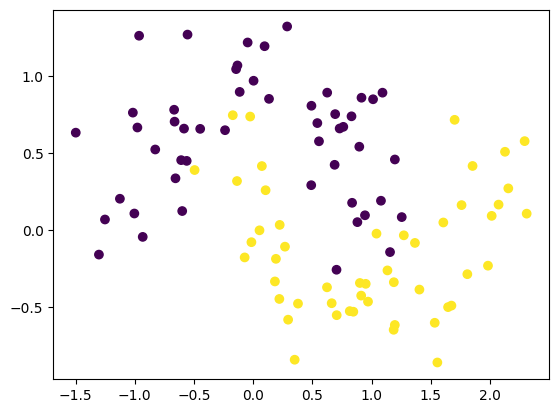

In [3]:
plt.scatter(x[:,0],x[:,1], c= y)
plt.show()

In [4]:
#without regularization

model1 = Sequential()
model1.add(Dense(128, activation = 'relu', input_dim = 2)),
model1.add(Dense(128, activation = 'relu')),
model1.add(Dense(1, activation = 'sigmoid'))

model1.summary()


/Users/rachin/Desktop/Ai/ai2.0/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
adam = Adam(learning_rate = 0.01)
model1.compile(loss = 'binary_crossentropy', optimizer= adam, metrics=['accuracy'])

history = model1.fit(x,y, epochs = 1000, validation_split = 0.2)

Epoch 1/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.9500 - loss: 0.0815 - val_accuracy: 0.9000 - val_loss: 0.8844
Epoch 2/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9625 - loss: 0.1545 - val_accuracy: 0.8500 - val_loss: 1.3643
Epoch 3/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9875 - loss: 0.0553 - val_accuracy: 0.9500 - val_loss: 0.6219
Epoch 4/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.0166 - val_accuracy: 0.9500 - val_loss: 0.2239
Epoch 5/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9750 - loss: 0.1049 - val_accuracy: 0.9500 - val_loss: 0.1690
Epoch 6/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.0045 - val_accuracy: 0.9500 - val_loss: 0.5033
Epoch 7/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 0.0037 - val_accuracy: 0.9000 - val_loss: 0.9229
Epoch 8/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9750 - loss: 0.0394 - val_accuracy: 0.9000 - v

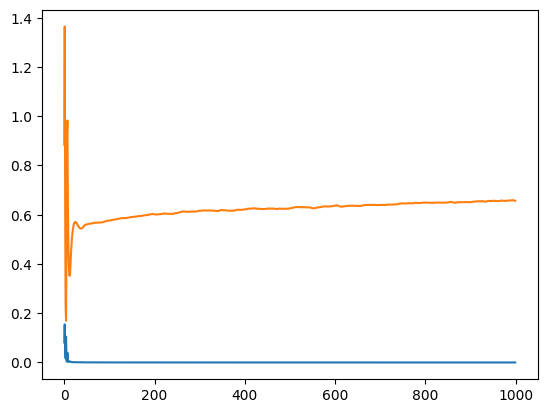

In [7]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.show()

In [8]:
## adding regularization term


model2 = Sequential()
model2.add(Dense(128, activation = 'relu', input_dim = 2, kernel_regularizer = tensorflow.keras.regularizers.l2(0.003))),
model2.add(Dense(128, activation = 'relu', kernel_regularizer = tensorflow.keras.regularizers.l2(0.003))),
model2.add(Dense(1, activation = 'sigmoid'))

model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
adam = Adam(learning_rate = 0.01)
model2.compile(loss = 'binary_crossentropy', optimizer= adam, metrics=['accuracy'])

history = model2.fit(x,y, epochs = 1000, validation_split = 0.2)

Epoch 1/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.7375 - loss: 0.9657 - val_accuracy: 0.9000 - val_loss: 0.6752
Epoch 2/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8125 - loss: 0.6972 - val_accuracy: 0.9000 - val_loss: 0.4934
Epoch 3/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8500 - loss: 0.6010 - val_accuracy: 0.9000 - val_loss: 0.4165
Epoch 4/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8500 - loss: 0.5187 - val_accuracy: 0.9000 - val_loss: 0.3714
Epoch 5/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8250 - loss: 0.5011 - val_accuracy: 0.8500 - val_loss: 0.3852
Epoch 6/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8375 - loss: 0.4718 - val_accuracy: 0.9000 - val_loss: 0.4071
Epoch 7/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8250 - loss: 0.4655 - val_accuracy: 0.9000 - val_loss: 0.3837
Epoch 8/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8500 - loss: 0.4481 - val_accuracy: 0.9000 - v

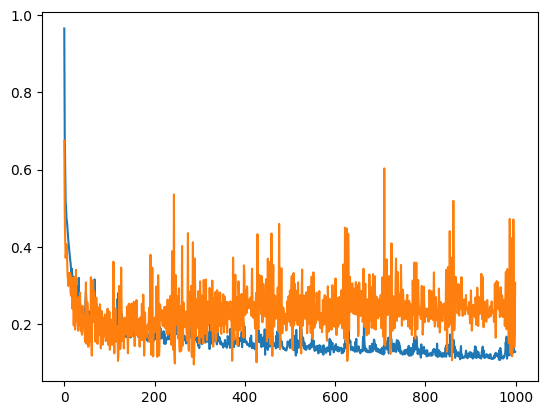

In [10]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.show()

In [11]:
model1_weight = model1.get_weights()[0].reshape(256)
model2_weight = model2.get_weights()[0].reshape(256)

<Axes: >

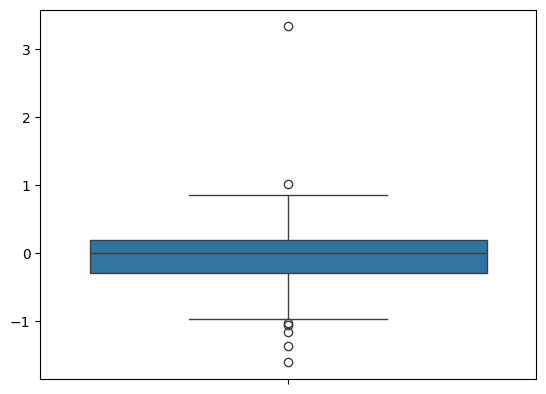

In [12]:
import seaborn as sns

sns.boxplot(model1_weight)

<Axes: >

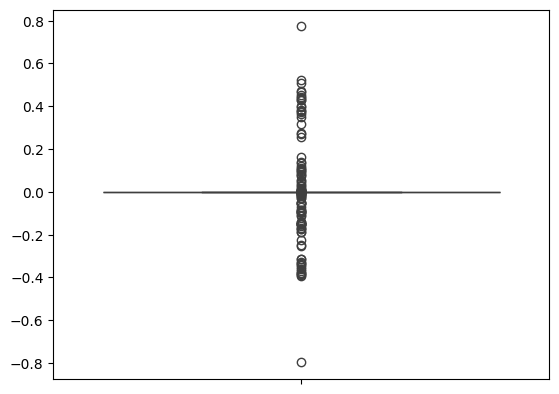

In [13]:
sns.boxplot(model2_weight)

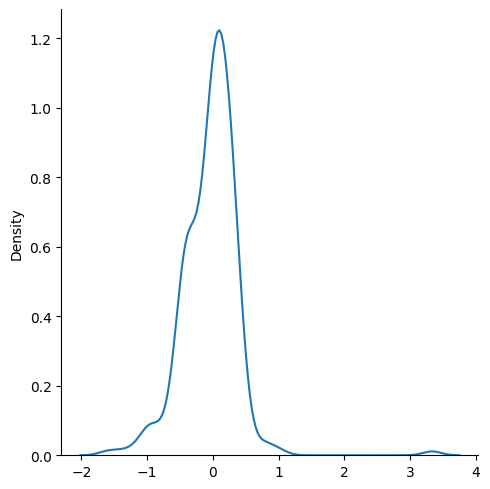

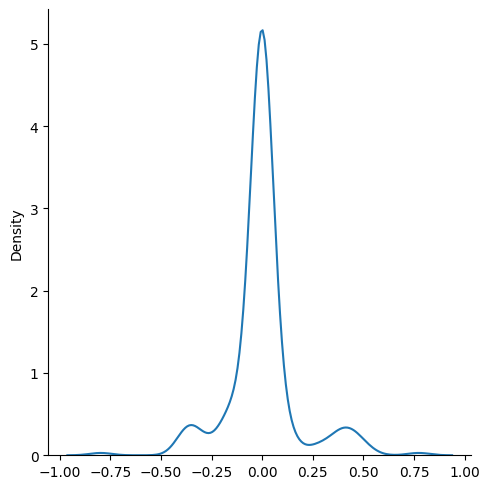

In [14]:
sns.displot(model1_weight, kind ='kde')
sns.displot(model2_weight,kind ='kde')
plt.show()

In [15]:
model1_weight.min()

np.float32(-1.600351)

In [16]:
model2_weight.min()

np.float32(-0.797009)

In [17]:
model1_weight.max()

np.float32(3.3363104)

In [18]:
model2_weight.max()

np.float32(0.77314085)